In [2]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import json
import drms
from astropy.time import Time
from pathlib import Path
import sunpy.map
import matplotlib.pyplot as plt
import os
import numpy as np
from astropy.io import fits
from PIL import Image
import pandas as pd

In [3]:
import json

def solarflare_query_processer(infile, output_info=1):
    # opening the file
    f = open(infile, 'r')
    # reading json part
    for line in f:
        if (line[0] == '{'):
            solarflare_obj = json.loads(line)
            break
    f.close()
    
    if (output_info == 1):
        print( "----------------------------------")
        print( "Possible dictionary keys (fields):")
        print ("----------------------------------")
        for key in solarflare_obj.keys():
            print(key)
        print ("---------------------------------------")
        print ("Example: use solarflare_obj['SOLID'][2] to access SOLID for the third flare")
    
    # returning headers and records
    return solarflare_obj

In [21]:
import drms
from astropy.time import Time
from pathlib import Path

JSOC_EMAIL = "652024260007@smail.nju.edu.cn"
HMI_SERIES = "hmi.Ic_45s"
OUT_DIR = Path("HMI")
OUT_DIR.mkdir(exist_ok=True)

client = drms.Client()
# 读取太阳耀斑数据文件
data = solarflare_query_processer('solarflareoutput_2026-05-12T00_53_31_45.txt', output_info=1)

# 访问第三个耀斑的SOLID标识符
#third_flare_id = data['SOLID'][2]

----------------------------------
Possible dictionary keys (fields):
----------------------------------
SOLID
UniqueID
Start Time
Peak Time
End Time
AR number
X, arcsec
Y, arcsec
GOES Class
GOES Max Temp, MK
GOES Max EM, 10<sup>49</sup> cm<sup>-3</sup>
GOES Duration, s
GOES T-EM Delay, s
RHESSI energy, keV
RHESSI duration, s
RHESSI peak, counts
HEK peak flux
HEK channel, <span>&#8491;</span>
---------------------------------------
Example: use solarflare_obj['SOLID'][2] to access SOLID for the third flare


In [23]:
# 找出 X, arcsec 或 Y, arcsec 为空的行索引
row_to_remove = []
for i in range(len(data['X, arcsec'])):
    if not data['X, arcsec'][i] or not data['Y, arcsec'][i]:
        row_to_remove.append(i)

print(f'去掉了 {len(row_to_remove)} 行')

# 过滤所有字段
data_remain = {
    key: [v for i, v in enumerate(values) if i not in row_to_remove]
    for key, values in data.items()
}

print(f'还剩 {len(data_remain["X, arcsec"])} 行')
'''
#展开了就是上面那个
data_remain = {}                          # 新建空字典
for key, values in data.items():          # 外层：遍历每个字段，如 'X, arcsec'、'GOES Class' 等
    filtered_values = []                  # 该字段过滤后的值列表
    for i, v in enumerate(values):        # 内层：遍历该字段的每一行，i 是行号，v 是值
        if i not in row_to_remove:        # 这行不在删除名单里
            filtered_values.append(v)     # 就保留
    data_remain[key] = filtered_values    # 把过滤后的列表存入新字典
'''


去掉了 0 行
还剩 3110 行


"\n#展开了就是上面那个\ndata_remain = {}                          # 新建空字典\nfor key, values in data.items():          # 外层：遍历每个字段，如 'X, arcsec'、'GOES Class' 等\n    filtered_values = []                  # 该字段过滤后的值列表\n    for i, v in enumerate(values):        # 内层：遍历该字段的每一行，i 是行号，v 是值\n        if i not in row_to_remove:        # 这行不在删除名单里\n            filtered_values.append(v)     # 就保留\n    data_remain[key] = filtered_values    # 把过滤后的列表存入新字典\n"

In [20]:
dataa={
    key: i for i in range(10) for key in ['a', 'b', 'c']
}
print(dataa)

{'a': 9, 'b': 9, 'c': 9}


In [4]:
#去掉相同的活动区
row_to_remove=[]
for i in range(1,len(data['Start Time'])):
    if data['AR number'][i]==data['AR number'][i-1]:
        row_to_remove.append(i)
print('去掉了多少行',len(row_to_remove))

data_unique={
    key: [value for i, value in enumerate(values) if i not in row_to_remove]
    for key, values in data.items()
}
print('还剩多少行',len(data_unique['Start Time']))

去掉了多少行 68
还剩多少行 47


In [24]:
# 按GOES Class首字母分成A/B/C/M/X五类
goes_classes = ['A', 'B', 'C', 'M', 'X']
data_by_class = {cls: {key: [] for key in data_remain.keys()} for cls in goes_classes}

for i in range(len(data_remain['GOES Class'])):
    goes_val = data_remain['GOES Class'][i]
    if goes_val and goes_val[0] in goes_classes:
        cls = goes_val[0]
        for key in data_remain.keys():
            data_by_class[cls][key].append(data_remain[key][i])

# 查看各类别数量
for cls in goes_classes:
    print(f"{cls}级耀斑: {len(data_by_class[cls]['GOES Class'])}个")

A级耀斑: 0个
B级耀斑: 930个
C级耀斑: 1999个
M级耀斑: 168个
X级耀斑: 13个


In [25]:
#保存时去掉ABCMX方便排序筛选
for key, value in data_by_class.items():
    for i in range(len(data_by_class[key]['GOES Class'])):
        data_by_class[key]['GOES Class'][i]=float(data_by_class[key]['GOES Class'][i][1:])

In [ ]:
#保存到本地excel中
for cls, cls_data in data_by_class.items():
    df = pd.DataFrame(cls_data)
    df.to_excel(f'{cls}级耀斑.xlsx', index=False)
    print(f'{cls}级耀斑: {len(df)}行 已保存')

A级耀斑: 0行 已保存
B级耀斑: 930行 已保存
C级耀斑: 1999行 已保存
M级耀斑: 168行 已保存
X级耀斑: 13行 已保存


In [ ]:
#检查发现TAI和UTC两个时间其实是不一样的
from astropy.time import Time
#TAI是原子钟时间，比UTC要多35秒的闰秒差距
def utc_to_tai_time(t_utc):
    return Time(t_utc, scale="utc").tai

t1=utc_to_tai_time(data_unique['Start Time'][0:3])
print(data_unique['Start Time'][0:3])
print(t1)

['2013-01-11 19:37:00', '2013-01-12 21:57:00', '2013-01-14 15:38:00']
['2013-01-11 19:37:35.000' '2013-01-12 21:57:35.000'
 '2013-01-14 15:38:35.000']


In [5]:
#修改时间格式，并找到最接近的有HMI的时间
def jsoc_trec_to_astropy_time(trec_str):
    """
    JSOC T_REC -> astropy Time (TAI)
    '2013.01.07_08:44:15_TAI' -> Time('2013-01-07T08:44:15', scale='tai')
    """
    s = trec_str
    if s.endswith("_TAI"):
        s = s[:-4]
    s = s.replace(".", "-", 2).replace("_", "T", 1)
    #print(Time(s, format="isot", scale="tai"))
    return Time(s, format="isot", scale="tai")


def find_nearest_hmi_record(t_utc, window=22*u.second):
    """
    在 ±window 内查找 hmi.Ic_45s 最近的一帧
    返回：最近帧的原始 JSOC T_REC 字符串
    """
    t_tai = Time(t_utc, scale="utc").tai

    t_start = (t_tai - window).strftime("%Y.%m.%d_%H:%M:%S_TAI")
    t_end   = (t_tai + window).strftime("%Y.%m.%d_%H:%M:%S_TAI")

    q = f"{HMI_SERIES}[{t_start}-{t_end}]"
    res = client.query(q, key="T_REC")

    if res is None or len(res) == 0:
        return None

    # bytes -> str
    trec_strs = [
        s.decode("utf-8") if isinstance(s, (bytes, bytearray)) else str(s)
        for s in res["T_REC"]
    ]

    # 转成 astropy Time
    trec_times = Time(
        [jsoc_trec_to_astropy_time(s) for s in trec_strs]
    )
    print(trec_times)
    dt = abs((trec_times - t_tai).to(u.second))
    idx = dt.argmin()

    return trec_strs[idx]

In [6]:
#下载HMI数据
def download_hmi_ic_nearest(t_utc, tag=None):
    """
    在 ±22s 内自动找最近 HMI Ic 帧并下载
    """
    nearest_trec = find_nearest_hmi_record(t_utc)
    print(nearest_trec)
    if nearest_trec is None:
        print(f"  [WARNING] No HMI Ic within ±22s of {t_utc}")
        return None

    qstr = f"{HMI_SERIES}[{nearest_trec}]{{continuum}}"
    print(f"  Exporting nearest record: {qstr}")

    export_req = client.export(
        qstr,
        method="url_quick",
        protocol="fits",
        email=JSOC_EMAIL,
    )

    if len(export_req.urls) == 0:
        print("  [WARNING] export returned no URLs")
        return None

    dl = export_req.download(str(OUT_DIR))
    local_files = dl.download

    if len(local_files) == 0:
        print("  [WARNING] download empty")
        return None

    fpath = Path(local_files[0])

    if tag is not None:
        new_name = OUT_DIR / f"{tag}_{fpath.name}"
        fpath.rename(new_name)
        fpath = new_name

    print(f"  Saved nearest HMI Ic: {fpath.name}")
    return fpath,nearest_trec


In [ ]:
#下载数据
error_list=[]
lost_list=[]
nearest_time=[None]*len(data_unique['Start Time'])
cnt=0
for i in range(len(data_unique['Start Time'])):
    try:
        fpath,nearest_trec=download_hmi_ic_nearest(data_unique['Start Time'][i])
        nearest_time[i]=nearest_trec
    except Exception as e:
        error_list.append(i)
    hmi_list=os.listdir(r'D:\AI in astronomy\HMI\\')
    if len(hmi_list)+cnt<i+1:
        cnt+=1
        lost_list.append(i)
print(error_list)
print(lost_list)

['2013-01-11T19:37:30.000' '2013-01-11T19:38:15.000']
2013.01.11_19:37:30_TAI
  Exporting nearest record: hmi.Ic_45s[2013.01.11_19:37:30_TAI]{continuum}


2025-12-27 11:48:36 - drms - INFO: Export request pending. [id=JSOC_20251227_000879, status=2]
2025-12-27 11:48:36 - drms - INFO: Waiting for 5 seconds...
2025-12-27 11:48:42 - drms - INFO: Downloading file 1 of 1...
2025-12-27 11:48:42 - drms - INFO:     record: hmi.Ic_45s[2013.01.11_19:37:30_TAI][2]
2025-12-27 11:48:42 - drms - INFO:     filename: hmi.ic_45s.20130111_193730_TAI.2.continuum.fits
2025-12-27 11:48:52 - drms - INFO:     -> HMI\hmi.ic_45s.20130111_193730_TAI.2.continuum.fits


  Saved nearest HMI Ic: hmi.ic_45s.20130111_193730_TAI.2.continuum.fits
['2013-01-12T21:57:00.000' '2013-01-12T21:57:45.000']
2013.01.12_21:57:45_TAI
  Exporting nearest record: hmi.Ic_45s[2013.01.12_21:57:45_TAI]{continuum}


2025-12-27 11:48:56 - drms - INFO: Export request pending. [id=JSOC_20251227_000900, status=2]
2025-12-27 11:48:56 - drms - INFO: Waiting for 5 seconds...
2025-12-27 11:49:02 - drms - INFO: Downloading file 1 of 1...
2025-12-27 11:49:02 - drms - INFO:     record: hmi.Ic_45s[2013.01.12_21:57:45_TAI][2]
2025-12-27 11:49:02 - drms - INFO:     filename: hmi.ic_45s.20130112_215745_TAI.2.continuum.fits
2025-12-27 11:49:10 - drms - INFO:     -> HMI\hmi.ic_45s.20130112_215745_TAI.2.continuum.fits


  Saved nearest HMI Ic: hmi.ic_45s.20130112_215745_TAI.2.continuum.fits
['2013-01-14T15:38:15.000' '2013-01-14T15:39:00.000']
2013.01.14_15:38:15_TAI
  Exporting nearest record: hmi.Ic_45s[2013.01.14_15:38:15_TAI]{continuum}


...

  Saved nearest HMI Ic: hmi.ic_45s.20131024_220515_TAI.2.continuum.fits
['2013-10-25T06:10:30.000' '2013-10-25T06:11:15.000']
2013.10.25_06:10:30_TAI
  Exporting nearest record: hmi.Ic_45s[2013.10.25_06:10:30_TAI]{continuum}


2025-12-27 12:16:21 - drms - INFO: Export request pending. [id=JSOC_20251227_001351, status=2]
2025-12-27 12:16:21 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:16:26 - drms - INFO: Export request pending. [id=JSOC_20251227_001351, status=1]
2025-12-27 12:16:26 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:16:32 - drms - INFO: Export request pending. [id=JSOC_20251227_001351, status=1]
2025-12-27 12:16:32 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:16:38 - drms - INFO: Export request pending. [id=JSOC_20251227_001351, status=1]
2025-12-27 12:16:38 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:16:43 - drms - INFO: Export request pending. [id=JSOC_20251227_001351, status=1]
2025-12-27 12:16:43 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:16:49 - drms - INFO: Downloading file 1 of 1...
2025-12-27 12:16:49 - drms - INFO:     record: hmi.Ic_45s[2013.10.25_06:10:30_TAI][2]
2025-12-27 12:16:49 - drms - INFO:     filename: hmi.ic_45s.20131025_061030_T

  Saved nearest HMI Ic: hmi.ic_45s.20131025_061030_TAI.2.continuum.fits
['2013-10-26T08:37:30.000' '2013-10-26T08:38:15.000']
2013.10.26_08:37:30_TAI
  Exporting nearest record: hmi.Ic_45s[2013.10.26_08:37:30_TAI]{continuum}


2025-12-27 12:16:59 - drms - INFO: Export request pending. [id=JSOC_20251227_001355, status=2]
2025-12-27 12:16:59 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:17:04 - drms - INFO: Export request pending. [id=JSOC_20251227_001355, status=1]
2025-12-27 12:17:04 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:17:10 - drms - INFO: Export request pending. [id=JSOC_20251227_001355, status=1]
2025-12-27 12:17:10 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:17:16 - drms - INFO: Export request pending. [id=JSOC_20251227_001355, status=1]
2025-12-27 12:17:16 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:17:21 - drms - INFO: Export request pending. [id=JSOC_20251227_001355, status=1]
2025-12-27 12:17:21 - drms - INFO: Waiting for 5 seconds...
2025-12-27 12:17:27 - drms - INFO: Downloading file 1 of 1...
2025-12-27 12:17:27 - drms - INFO:     record: hmi.Ic_45s[2013.10.26_08:37:30_TAI][2]
2025-12-27 12:17:27 - drms - INFO:     filename: hmi.ic_45s.20131026_083730_T

  Saved nearest HMI Ic: hmi.ic_45s.20131026_083730_TAI.2.continuum.fits
[34]


In [ ]:
print(error_list)
#这里非常有趣，这个数据其实是有的，没下载成功而已，但是下一个数据有这个时间但
#JSCO上没有fits文件的

[34]


In [8]:
for keys in data_unique:
    del data_unique[keys][35]

In [11]:
try:
    download_hmi_ic_nearest(data_unique['Start Time'][35])
except:
    print('error')

['2013-10-13T17:50:15.000' '2013-10-13T17:51:00.000']
2013.10.13_17:50:15_TAI
  Exporting nearest record: hmi.Ic_45s[2013.10.13_17:50:15_TAI]{continuum}


2025-12-27 13:05:59 - drms - INFO: Export request pending. [id=JSOC_20251226_000846, status=2]
2025-12-27 13:05:59 - drms - INFO: Waiting for 5 seconds...
2025-12-27 13:06:05 - drms - INFO: Downloading file 1 of 1...
2025-12-27 13:06:05 - drms - INFO:     record: warning=No FITS files were exported. The requested FITS files no longer exist.
2025-12-27 13:06:05 - drms - INFO:     filename: 
2025-12-27 13:06:07 - drms - INFO:     -> HMI.3


  Saved nearest HMI Ic: HMI.3


-525.8 231.3


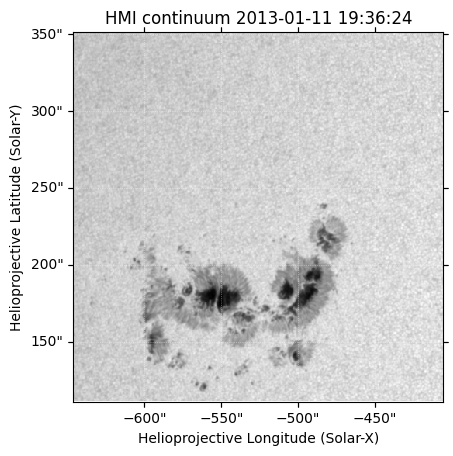

In [ ]:
#检查是否选到了黑子区域
name_list=os.listdir(r'D:\AI in astronomy\HMI\\')
m=sunpy.map.Map(r'D:\AI in astronomy\HMI\\'+name_list[0])
m_rot=m.rotate()
width=120
bottom_left=SkyCoord(Tx=(float(data['X, arcsec'][0])-width)*u.arcsec, 
                     Ty=(float(data['Y, arcsec'][0])-width)*u.arcsec, frame=m_rot.coordinate_frame)
top_right=SkyCoord(Tx=(float(data['X, arcsec'][0])+width)*u.arcsec, 
                   Ty=(float(data['Y, arcsec'][0])+width)*u.arcsec, frame=m_rot.coordinate_frame)
sub_map=m_rot.submap(bottom_left, top_right=top_right)
sub_map.plot()
print(data['X, arcsec'][0],data['Y, arcsec'][0])

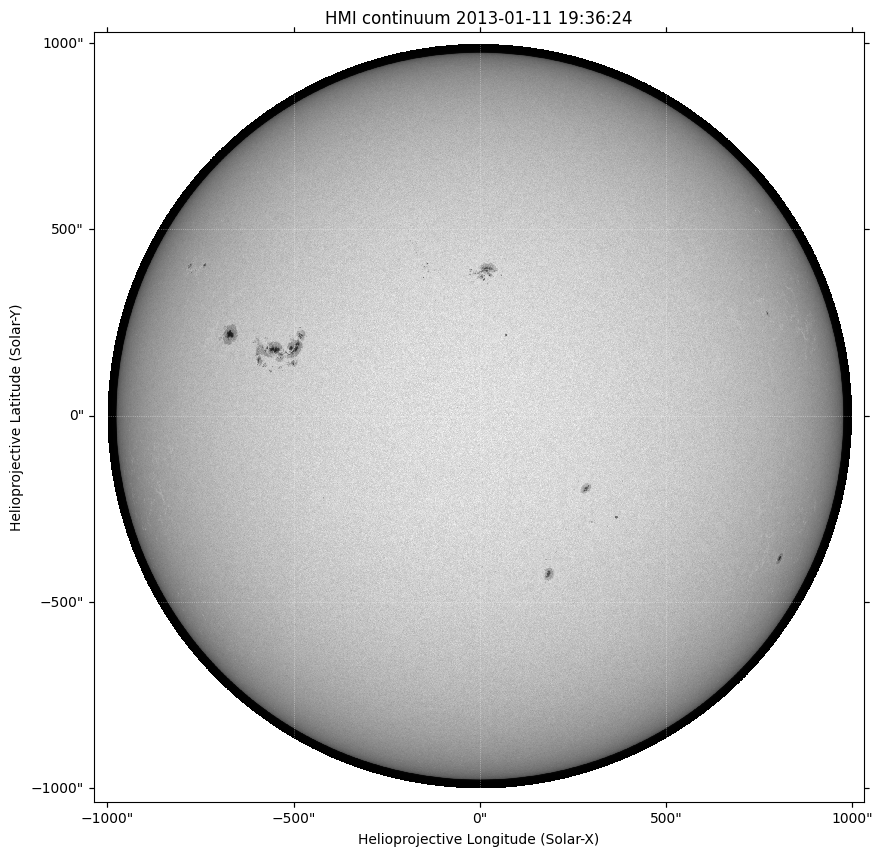

In [69]:
plt.figure(figsize=(10, 10))
m_rot.plot()

In [ ]:
def fits_to_grayscale_png(
    fits_path,
    out_path,
    output_name,
    Tx,Ty,
    vmin=None,vmax=None
):
    """
    将 FITS 文件转换为无边框灰度 PNG 图像
    """
    m=sunpy.map.Map(fits_path)
    m_rot=m.rotate()
    bot_left=SkyCoord(Tx=Tx[0]*u.arcsec,Ty=Ty[0]*u.arcsec,
                      frame=m_rot.coordinate_frame)
    top_right=SkyCoord(Tx=Tx[1]*u.arcsec,Ty=Ty[1]*u.arcsec,
                      frame=m_rot.coordinate_frame)
    m_sub_rot=m_rot.submap(bot_left,top_right=top_right)
    data=m_sub_rot.data
    data=np.flipud(data)
    ny,nx=data.shape

    # 2. 去除 NaN / Inf
    data = np.nan_to_num(data)

    # 3. 强度拉伸（如果不指定，使用百分位）
    if vmin is None:
        vmin = np.percentile(data, 1)
    if vmax is None:
        vmax = np.percentile(data, 99)

    data = np.clip(data, vmin, vmax)

    # 4. 归一化到 [0, 255]
    data_norm = (data - vmin) / (vmax - vmin)
    data_uint8 = (255 * data_norm).astype(np.uint8)

    # 5. 保存为灰度图（L 模式）
    img = Image.fromarray(data_uint8, mode="L")
    img.save(out_path + output_name)
    return ny,nx

In [10]:
name_list=os.listdir(r'D:\AI in astronomy\HMI\\')
NY=[]
NX=[]
for i in range(len(name_list)):
    ny,nx=fits_to_grayscale_png(
        fits_path=r'D:\AI in astronomy\HMI\\'+name_list[i],
        out_path=r'D:\AI in astronomy\png\\',
        output_name=name_list[i].replace('.fits','.png'),
        Tx=[(float(data_unique['X, arcsec'][i])-120),(float(data_unique['X, arcsec'][i])+120)],
        Ty=[(float(data_unique['Y, arcsec'][i])-120),(float(data_unique['Y, arcsec'][i])+120)],
    )
    NY.append(ny)
    NX.append(nx)
data_unique['NX']=NX
data_unique['NY']=NY

In [71]:
data['nx']=[1,2,3]

In [72]:
del data['nx']

In [12]:
df=pd.DataFrame(data_unique)
df.to_excel('unique_list.xlsx')